# METODE B: ViT Fine-tuning (BALANCED + FOCAL LOSS)
## ECG Myocardial Infarction Classification

### 🎯 Target:
- Accuracy: 87-89%
- GAP: < 5%
- F1 Macro: > 0.55
- IMI/AMI Recall: > 30%

### 🔧 Perubahan dari Versi Sebelumnya:

| Aspek | Untuned | Over-tuned | BALANCED |
|-------|---------|------------|----------|
| LR Backbone | 2e-5 | 1e-5 | **1.5e-5** |
| LR Head | 1e-3 | 5e-4 | **8e-4** |
| Weight Decay | 0.01 | 0.05 | **0.02** |
| Dropout | 0 | 0.3 | **0.15** |
| Label Smoothing | 0 | 0.1 | **0.05** |
| Patience | 7 | 4 | **5** |
| Loss | CE | CE | **Focal Loss** |

### 🔥 Focal Loss:
- Fokus ke sample yang SUSAH diprediksi
- Membantu minority class (AMI, IMI) tanpa over-regularisasi

## 1. Setup & Download Data

In [1]:
# Install dependencies
!pip install -q gdown transformers pillow tqdm scikit-learn seaborn
!apt-get update -qq && apt-get install -y -qq unrar

import gdown
import subprocess
import os

# Download dari Google Drive
FILE_ID = "18IjP8_q8V0-m1tjvVRhJmBADCv4Iri8_"
RAR_PATH = "/workspace/png_segments.rar"
EXTRACT_TO = "/workspace/data/"

# Skip jika data sudah ada
if os.path.exists("/workspace/data/png_segments/NORM"):
    print("✅ Data sudah ada, skip download")
else:
    print("📥 Downloading... (tunggu ~10-15 menit)")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", RAR_PATH, quiet=True, fuzzy=True)

    if os.path.exists(RAR_PATH):
        size_gb = os.path.getsize(RAR_PATH) / (1024**3)
        print(f"✅ Download complete! Size: {size_gb:.2f} GB")
        
        print("\n📦 Extracting...")
        os.makedirs(EXTRACT_TO, exist_ok=True)
        result = subprocess.run(['unrar', 'x', '-o+', '-y', RAR_PATH, EXTRACT_TO], capture_output=True)
        
        if result.returncode == 0:
            print("✅ Extract complete!")
            os.remove(RAR_PATH)
            print("🗑️ RAR deleted")
        else:
            print(f"❌ Error: {result.stderr.decode()}")
    else:
        print("❌ Download failed")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
✅ Data sudah ada, skip download


## 2. Import Libraries

In [2]:
import os, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from datetime import datetime
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Set seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available(): 
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Device: cuda
   GPU: NVIDIA GeForce RTX 3090


## 3. Configuration (BALANCED)

In [3]:
# === CONFIGURATION (BALANCED) ===
PNG_SEGMENTS_DIR = "/workspace/data/png_segments"
OUTPUT_DIR = "/workspace/output_method_b_balanced"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "google/vit-base-patch16-224"
TARGET_CLASSES = ['NORM', 'AMI', 'ASMI', 'ILMI', 'IMI']
NUM_CLASSES = len(TARGET_CLASSES)
CLASS_TO_IDX = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

# ========== BALANCED HYPERPARAMETERS ==========
BATCH_SIZE = 32
NUM_EPOCHS = 15
PATIENCE = 5              # Antara 4 dan 7

LR_BACKBONE = 1.5e-5      # Antara 1e-5 dan 2e-5
LR_HEAD = 8e-4            # Antara 5e-4 dan 1e-3
WEIGHT_DECAY = 0.02       # Antara 0.01 dan 0.05
WARMUP_EPOCHS = 2

DROPOUT_RATE = 0.15       # Lebih kecil dari 0.3
LABEL_SMOOTHING = 0.05    # Lebih kecil dari 0.1

# FOCAL LOSS PARAMETERS
FOCAL_GAMMA = 2.0         # Fokus ke hard samples (standard: 2.0)

USE_AMP = True
# ================================================

print("="*60)
print("⚖️ BALANCED HYPERPARAMETERS + FOCAL LOSS")
print("="*60)
print(f"   Batch Size:      {BATCH_SIZE}")
print(f"   Epochs:          {NUM_EPOCHS}")
print(f"   Early Stop:      Patience={PATIENCE}")
print(f"   LR Backbone:     {LR_BACKBONE}")
print(f"   LR Head:         {LR_HEAD}")
print(f"   Weight Decay:    {WEIGHT_DECAY}")
print(f"   Dropout:         {DROPOUT_RATE}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")
print(f"   Focal Gamma:     {FOCAL_GAMMA}")
print("="*60)

⚖️ BALANCED HYPERPARAMETERS + FOCAL LOSS
   Batch Size:      32
   Epochs:          15
   Early Stop:      Patience=5
   LR Backbone:     1.5e-05
   LR Head:         0.0008
   Weight Decay:    0.02
   Dropout:         0.15
   Label Smoothing: 0.05
   Focal Gamma:     2.0


## 4. Collect & Split Data

In [4]:
# === COLLECT DATA ===
data = []
for c in TARGET_CLASSES:
    cd = os.path.join(PNG_SEGMENTS_DIR, c)
    if not os.path.exists(cd): continue
    for ecg in tqdm(os.listdir(cd), desc=c):
        ep = os.path.join(cd, ecg)
        if os.path.isdir(ep):
            for f in os.listdir(ep):
                if f.endswith('.png'):
                    data.append({'image_path': os.path.join(ep,f), 'label': c, 'label_idx': CLASS_TO_IDX[c], 'ecg_id': ecg})
df = pd.DataFrame(data)
print(f"\n✅ {len(df):,} segments from {df['ecg_id'].nunique():,} ECGs")

# Show class distribution
print("\n📊 Class Distribution:")
for c in TARGET_CLASSES:
    count = len(df[df['label'] == c])
    pct = count / len(df) * 100
    print(f"   {c}: {count:,} ({pct:.1f}%)")

IMI: 100%|██████████| 1517/1517 [00:00<00:00, 31931.94it/s]



✅ 131,580 segments from 13,158 ECGs

📊 Class Distribution:
   NORM: 94,380 (71.7%)
   AMI: 1,790 (1.4%)
   ASMI: 16,790 (12.8%)
   ILMI: 3,450 (2.6%)
   IMI: 15,170 (11.5%)


In [5]:
# === PATIENT-WISE SPLIT ===
ecg_labels = df.groupby('ecg_id')['label'].first().reset_index()
train_val, test_ecg = train_test_split(ecg_labels, test_size=0.2, stratify=ecg_labels['label'], random_state=SEED)
train_ecg, val_ecg = train_test_split(train_val, test_size=0.125, stratify=train_val['label'], random_state=SEED)

df['split'] = 'train'
df.loc[df['ecg_id'].isin(val_ecg['ecg_id']), 'split'] = 'val'
df.loc[df['ecg_id'].isin(test_ecg['ecg_id']), 'split'] = 'test'

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df = df[df['split']=='val'].reset_index(drop=True)
test_df = df[df['split']=='test'].reset_index(drop=True)

print(f"📊 Data Split:")
print(f"   Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Val:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

📊 Data Split:
   Train: 92,100 (70.0%)
   Val:   13,160 (10.0%)
   Test:  26,320 (20.0%)


## 5. Dataset dengan Data Augmentation (Ringan)

In [6]:
# === DATA AUGMENTATION (RINGAN) ===
# Augmentasi lebih ringan untuk balanced approach

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.2),           # Dikurangi dari 0.3
    transforms.RandomRotation(3),                      # Dikurangi dari 5
    transforms.ColorJitter(brightness=0.05, contrast=0.05),  # Dikurangi
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("✅ Data Augmentation (Light):")
print("   Train: Light Flip, Light Rotation, Light ColorJitter")
print("   Val/Test: No augmentation")

✅ Data Augmentation (Light):
   Train: Light Flip, Light Rotation, Light ColorJitter
   Val/Test: No augmentation


In [7]:
# === DATASET CLASS ===
class ECGDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(row['label_idx'], dtype=torch.long)
        return {'pixel_values': img, 'labels': label}

# Create datasets
train_dataset = ECGDataset(train_df, transform=train_transform)
val_dataset = ECGDataset(val_df, transform=val_test_transform)
test_dataset = ECGDataset(test_df, transform=val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=4, pin_memory=True)

print(f"✅ DataLoaders created:")
print(f"   Train: {len(train_loader)} batches")
print(f"   Val:   {len(val_loader)} batches")
print(f"   Test:  {len(test_loader)} batches")

✅ DataLoaders created:
   Train: 2878 batches
   Val:   412 batches
   Test:  823 batches


## 6. Focal Loss Implementation

### 🔥 Apa itu Focal Loss?

```
CROSS ENTROPY LOSS:
- Semua sample dianggap sama pentingnya
- Sample mudah (NORM) dapat loss yang sama dengan sample susah (AMI)
- Model fokus ke kelas mayoritas

FOCAL LOSS:
- Sample MUDAH → loss dikurangi (model sudah bisa)
- Sample SUSAH → loss tetap besar (model perlu belajar)
- Model FOKUS ke kelas yang susah diprediksi

FORMULA:
FL(p) = -α * (1-p)^γ * log(p)

- p = probabilitas prediksi benar
- γ (gamma) = focusing parameter (biasanya 2.0)
- α (alpha) = class weight

CONTOH:
- NORM diprediksi 95% benar → (1-0.95)^2 = 0.0025 → loss sangat kecil
- AMI diprediksi 30% benar → (1-0.30)^2 = 0.49 → loss tetap besar
```

In [8]:
# === FOCAL LOSS IMPLEMENTATION ===

class FocalLoss(nn.Module):
    """
    Focal Loss untuk menangani class imbalance.
    
    Paper: "Focal Loss for Dense Object Detection" (Lin et al., 2017)
    
    FL(p) = -α * (1-p)^γ * log(p)
    
    Args:
        alpha: Class weights (tensor)
        gamma: Focusing parameter (default: 2.0)
        label_smoothing: Label smoothing factor (default: 0.0)
    """
    
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Class weights
        self.gamma = gamma  # Focusing parameter
        self.label_smoothing = label_smoothing
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        """
        Args:
            inputs: Predictions (logits) [batch_size, num_classes]
            targets: Ground truth labels [batch_size]
        """
        num_classes = inputs.size(1)
        
        # Apply label smoothing
        if self.label_smoothing > 0:
            # Convert to one-hot
            targets_one_hot = F.one_hot(targets, num_classes).float()
            # Apply smoothing
            targets_smooth = targets_one_hot * (1 - self.label_smoothing) + \
                           self.label_smoothing / num_classes
        else:
            targets_smooth = F.one_hot(targets, num_classes).float()
        
        # Calculate probabilities
        p = F.softmax(inputs, dim=1)
        
        # Get probability for correct class
        p_t = (p * targets_smooth).sum(dim=1)
        
        # Calculate focal weight
        focal_weight = (1 - p_t) ** self.gamma
        
        # Calculate cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # Apply focal weight
        focal_loss = focal_weight * ce_loss
        
        # Apply class weights (alpha)
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        # Reduction
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("✅ Focal Loss implemented!")
print(f"   Gamma: {FOCAL_GAMMA}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")

✅ Focal Loss implemented!
   Gamma: 2.0
   Label Smoothing: 0.05


## 7. Model dengan Custom Classifier

In [9]:
# === LOAD MODEL ===
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=NUM_CLASSES, 
    id2label=IDX_TO_CLASS, 
    label2id=CLASS_TO_IDX, 
    ignore_mismatched_sizes=True
)

# === CUSTOM CLASSIFIER DENGAN DROPOUT (BALANCED) ===
model.classifier = nn.Sequential(
    nn.Dropout(DROPOUT_RATE),           # 0.15 (balanced)
    nn.Linear(768, 256),                
    nn.GELU(),                          # GELU instead of ReLU (smoother)
    nn.Dropout(DROPOUT_RATE * 0.5),     # 0.075
    nn.Linear(256, NUM_CLASSES)         
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model loaded with custom classifier:")
print(f"   Total params:     {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"\n📋 Custom Classifier Architecture:")
print(model.classifier)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([5, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Model loaded with custom classifier:
   Total params:     85,996,805
   Trainable params: 85,996,805

📋 Custom Classifier Architecture:
Sequential(
  (0): Dropout(p=0.15, inplace=False)
  (1): Linear(in_features=768, out_features=256, bias=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.075, inplace=False)
  (4): Linear(in_features=256, out_features=5, bias=True)
)


## 8. Training Setup

In [10]:
# === CLASS WEIGHTS ===
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("📊 Class Weights:")
for c, w in zip(TARGET_CLASSES, class_weights):
    print(f"   {c}: {w:.4f}")

# === FOCAL LOSS ===
criterion = FocalLoss(
    alpha=class_weights,
    gamma=FOCAL_GAMMA,
    label_smoothing=LABEL_SMOOTHING
)

print(f"\n✅ Loss: Focal Loss")
print(f"   Gamma: {FOCAL_GAMMA}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")

📊 Class Weights:
   NORM: 2.8417
   AMI: 0.3023
   ASMI: 1.4678
   ILMI: 0.3345
   IMI: 0.0538

✅ Loss: Focal Loss
   Gamma: 2.0
   Label Smoothing: 0.05


In [11]:
# === OPTIMIZER ===
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
classifier_params = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': classifier_params, 'lr': LR_HEAD}
], weight_decay=WEIGHT_DECAY)

print(f"✅ Optimizer: AdamW")
print(f"   Backbone LR:   {LR_BACKBONE}")
print(f"   Classifier LR: {LR_HEAD}")
print(f"   Weight Decay:  {WEIGHT_DECAY}")

✅ Optimizer: AdamW
   Backbone LR:   1.5e-05
   Classifier LR: 0.0008
   Weight Decay:  0.02


In [12]:
# === LEARNING RATE SCHEDULER ===
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = len(train_loader) * WARMUP_EPOCHS

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    else:
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = GradScaler()

print(f"✅ Scheduler: Warmup ({WARMUP_EPOCHS} epochs) + Cosine Decay")

✅ Scheduler: Warmup (2 epochs) + Cosine Decay


## 9. Training Functions

In [13]:
def train_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in tqdm(loader, desc="Train", leave=False):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, f1, f1_macro

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    for batch in tqdm(loader, desc="Eval", leave=False):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(pixel_values=pixel_values)
        loss = criterion(outputs.logits, labels)
        
        total_loss += loss.item()
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, f1, f1_macro, np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("✅ Training functions defined")

✅ Training functions defined


## 10. Training Loop

In [14]:
# === TRAINING LOOP ===
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [], 'train_f1_macro': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_f1_macro': [], 'lr': []
}

best_val_f1_macro = 0  # Track F1 Macro instead of just F1
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0

print("="*100)
print("🚀 TRAINING - METODE B (ViT) - BALANCED + FOCAL LOSS")
print("="*100)
print(f"{'Ep':^4}|{'Tr Loss':^9}|{'Tr Acc':^8}|{'Tr F1M':^8}|{'Val Loss':^9}|{'Val Acc':^8}|{'Val F1M':^8}|{'GAP':^6}|{'LR':^10}")
print("-"*100)

train_start_time = datetime.now()

for epoch in range(NUM_EPOCHS):
    # Training
    train_loss, train_acc, train_f1, train_f1_macro = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, device
    )
    
    # Validation
    val_loss, val_acc, val_f1, val_f1_macro, _, _, _ = evaluate(model, val_loader, criterion, device)
    
    current_lr = optimizer.param_groups[0]['lr']
    gap = (train_acc - val_acc) * 100
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['train_f1_macro'].append(train_f1_macro)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_f1_macro'].append(val_f1_macro)
    history['lr'].append(current_lr)
    
    # Best model based on Val F1 Macro (better for imbalanced data)
    is_best = val_f1_macro > best_val_f1_macro
    if is_best:
        best_val_f1_macro = val_f1_macro
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_f1_macro': val_f1_macro,
            'val_acc': val_acc
        }, os.path.join(OUTPUT_DIR, 'best_model.pth'))
    else:
        patience_counter += 1
    
    gap_icon = "✅" if gap < 5 else "⚠️" if gap < 10 else "❌"
    best_marker = " 🏆" if is_best else ""
    print(f"{epoch+1:^4}|{train_loss:^9.4f}|{train_acc:^8.4f}|{train_f1_macro:^8.4f}|{val_loss:^9.4f}|{val_acc:^8.4f}|{val_f1_macro:^8.4f}|{gap:^5.1f}%{gap_icon}|{current_lr:^10.2e}{best_marker}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping at epoch {epoch+1}")
        break

train_time = datetime.now() - train_start_time
print("-"*100)
print(f"🏆 Best: Epoch {best_epoch}, Val F1 Macro: {best_val_f1_macro:.4f}")
print(f"⏱️ Training time: {train_time}")

🚀 TRAINING - METODE B (ViT) - BALANCED + FOCAL LOSS
 Ep | Tr Loss | Tr Acc | Tr F1M |Val Loss |Val Acc |Val F1M | GAP  |    LR    
----------------------------------------------------------------------------------------------------


 1  | 0.2093  | 0.7843 | 0.3059 | 0.1010  | 0.8249 | 0.3755 |-4.1 %✅| 7.50e-06  🏆


 2  | 0.1139  | 0.8232 | 0.3845 | 0.0901  | 0.8405 | 0.4350 |-1.7 %✅| 1.50e-05  🏆


 3  | 0.0913  | 0.8399 | 0.4468 | 0.0763  | 0.8591 | 0.5054 |-1.9 %✅| 1.48e-05  🏆


 4  | 0.0756  | 0.8538 | 0.4912 | 0.0728  | 0.8517 | 0.4696 | 0.2 %✅| 1.41e-05 


...

 11 | 0.0210  | 0.9238 | 0.8071 | 0.2058  | 0.8843 | 0.6249 | 3.9 %✅| 3.24e-06 


 12 | 0.0186  | 0.9312 | 0.8340 | 0.2647  | 0.8854 | 0.6223 | 4.6 %✅| 1.89e-06 


 13 | 0.0158  | 0.9370 | 0.8530 | 0.2639  | 0.8851 | 0.6258 | 5.2 %⚠️| 8.59e-07 


 14 | 0.0133  | 0.9402 | 0.8605 | 0.2811  | 0.8864 | 0.6250 | 5.4 %⚠️| 2.18e-07 


 15 | 0.0120  | 0.9427 | 0.8714 | 0.2839  | 0.8859 | 0.6254 | 5.7 %⚠️| 0.00e+00 

⚠️ Early stopping at epoch 15
----------------------------------------------------------------------------------------------------
🏆 Best: Epoch 10, Val F1 Macro: 0.6258
⏱️ Training time: 1:16:20.495267


## 11. Training Curves

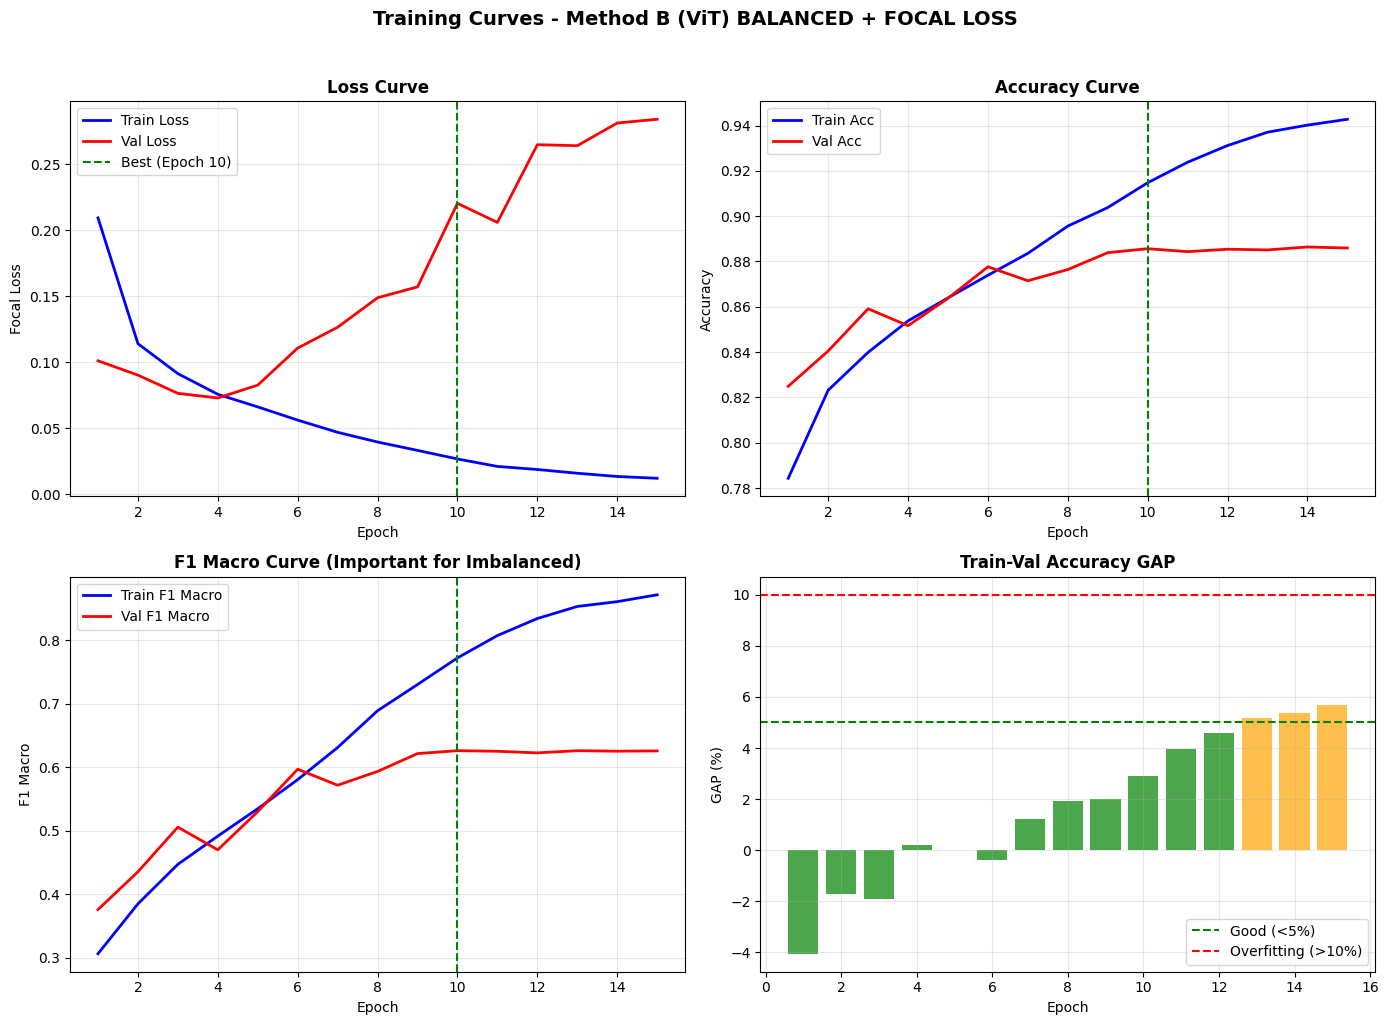

✅ Saved: training_curves.png


In [15]:
# === TRAINING CURVES ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
ax1 = axes[0, 0]
ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.axvline(best_epoch, color='g', linestyle='--', label=f'Best (Epoch {best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Focal Loss')
ax1.set_title('Loss Curve', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2 = axes[0, 1]
ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
ax2.axvline(best_epoch, color='g', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# F1 Macro (IMPORTANT for imbalanced data)
ax3 = axes[1, 0]
ax3.plot(epochs_range, history['train_f1_macro'], 'b-', label='Train F1 Macro', linewidth=2)
ax3.plot(epochs_range, history['val_f1_macro'], 'r-', label='Val F1 Macro', linewidth=2)
ax3.axvline(best_epoch, color='g', linestyle='--')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('F1 Macro')
ax3.set_title('F1 Macro Curve (Important for Imbalanced)', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# GAP
ax4 = axes[1, 1]
gap_values = [(t - v) * 100 for t, v in zip(history['train_acc'], history['val_acc'])]
colors = ['green' if g <= 5 else 'orange' if g <= 10 else 'red' for g in gap_values]
ax4.bar(epochs_range, gap_values, color=colors, alpha=0.7)
ax4.axhline(5, color='green', linestyle='--', label='Good (<5%)')
ax4.axhline(10, color='red', linestyle='--', label='Overfitting (>10%)')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('GAP (%)')
ax4.set_title('Train-Val Accuracy GAP', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle('Training Curves - Method B (ViT) BALANCED + FOCAL LOSS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: training_curves.png")

## 12. Load Best Model & Evaluate

In [16]:
# === LOAD BEST MODEL ===
checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Val F1 Macro: {checkpoint['val_f1_macro']:.4f}")

✅ Loaded best model from epoch 10
   Val F1 Macro: 0.6258


In [17]:
# === FINAL EVALUATION ON TEST SET ===
print("\n📊 Evaluating on TEST SET...")
test_loss, test_acc, test_f1, test_f1_macro, y_true, y_pred, y_probs = evaluate(
    model, test_loader, criterion, device
)

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

print(f"\n{'='*50}")
print(f"🎯 TEST SET RESULTS")
print(f"{'='*50}")
print(f"   Accuracy:      {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1 Weighted:   {test_f1:.4f}")
print(f"   F1 Macro:      {test_f1_macro:.4f}")
print(f"   Precision:     {precision_weighted:.4f}")
print(f"   Recall:        {recall_weighted:.4f}")


📊 Evaluating on TEST SET...



🎯 TEST SET RESULTS
   Accuracy:      0.8866 (88.66%)
   F1 Weighted:   0.8775
   F1 Macro:      0.6108
   Precision:     0.8812
   Recall:        0.8866


In [18]:
# === PER-CLASS METRICS ===
print(f"\n📊 Per-Class Metrics:")
metrics_df = pd.DataFrame({
    'Class': TARGET_CLASSES,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1': f1_per_class,
    'Support': [sum(y_true == i) for i in range(NUM_CLASSES)]
}).round(4)
print(metrics_df.to_string(index=False))

metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'per_class_metrics.csv'), index=False)

# Classification Report
report = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4)
print(f"\n📊 Classification Report:")
print(report)

with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)


📊 Per-Class Metrics:
Class  Precision  Recall     F1  Support
 NORM     0.9367  0.9845 0.9600    18880
  AMI     0.1629  0.0806 0.1078      360
 ASMI     0.7469  0.8336 0.7879     3360
 ILMI     0.5393  0.6159 0.5751      690
  IMI     0.8478  0.4927 0.6233     3030

📊 Classification Report:
              precision    recall  f1-score   support

        NORM     0.9367    0.9845    0.9600     18880
         AMI     0.1629    0.0806    0.1078       360
        ASMI     0.7469    0.8336    0.7879      3360
        ILMI     0.5393    0.6159    0.5751       690
         IMI     0.8478    0.4927    0.6233      3030

    accuracy                         0.8866     26320
   macro avg     0.6467    0.6015    0.6108     26320
weighted avg     0.8812    0.8866    0.8775     26320



## 13. Confusion Matrix

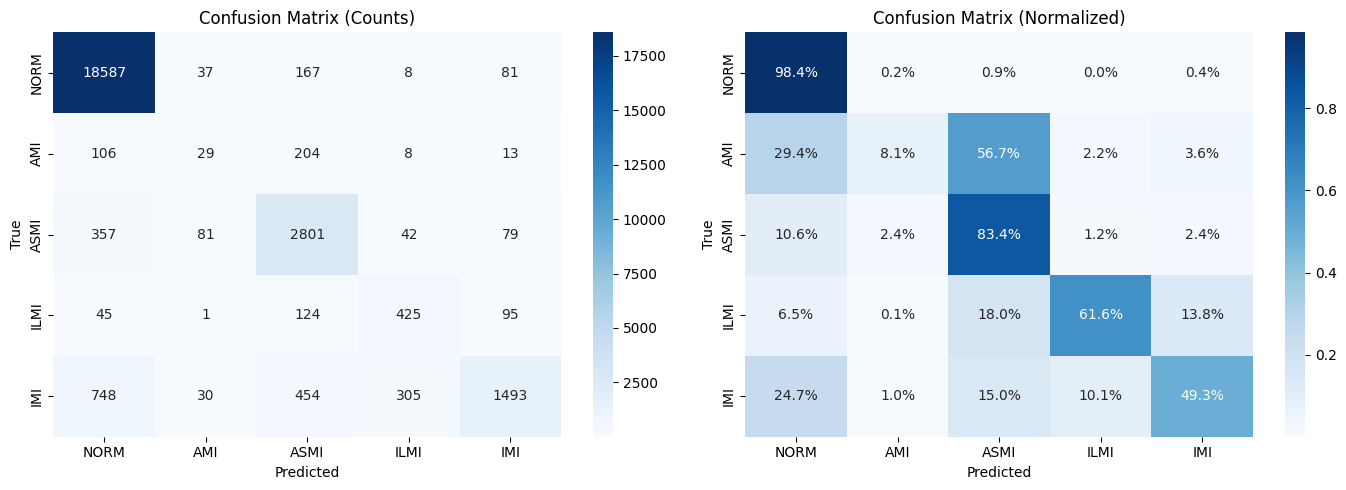

✅ Saved: confusion_matrix.png


In [19]:
# === CONFUSION MATRIX ===
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)')

sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png")

## 14. ROC Curves

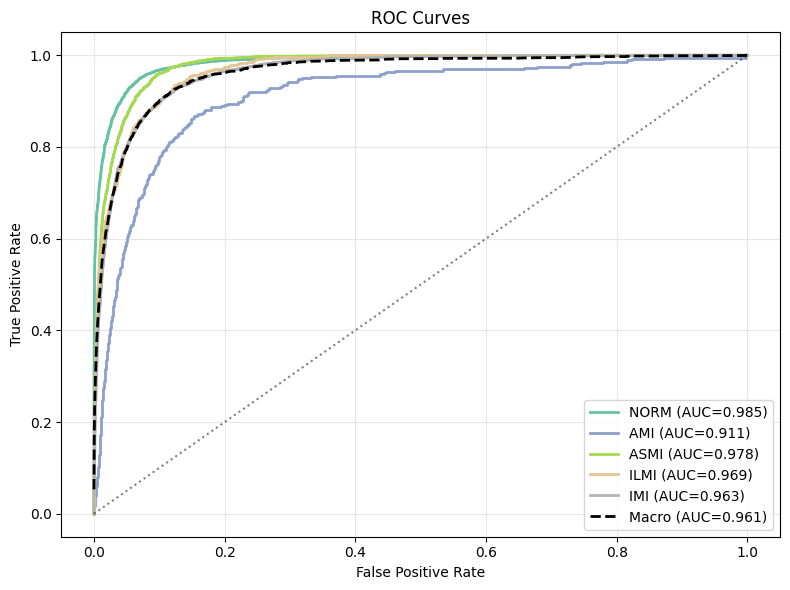


📊 AUC Scores:
   NORM: 0.9846
   AMI: 0.9114
   ASMI: 0.9785
   ILMI: 0.9688
   IMI: 0.9631
   Macro: 0.9613


In [20]:
# === ROC CURVES ===
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
aucs = []

for i, (class_name, color) in enumerate(zip(TARGET_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC={roc_auc:.3f})')

all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_probs[:, i])[0] for i in range(NUM_CLASSES)]))
mean_tpr = np.mean([np.interp(all_fpr, *roc_curve(y_true_bin[:, i], y_probs[:, i])[:2]) for i in range(NUM_CLASSES)], axis=0)
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', lw=2, label=f'Macro (AUC={macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150)
plt.show()

print(f"\n📊 AUC Scores:")
for class_name, auc_score in zip(TARGET_CLASSES, aucs):
    print(f"   {class_name}: {auc_score:.4f}")
print(f"   Macro: {macro_auc:.4f}")

## 15. Save All Results

In [21]:
# === SAVE RESULTS ===
results = {
    'method': 'B - ViT Fine-tuning (BALANCED + FOCAL LOSS)',
    'model': MODEL_NAME,
    'params': total_params,
    'dataset': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df)
    },
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history['train_loss']),
        'best_epoch': best_epoch,
        'lr_backbone': LR_BACKBONE,
        'lr_head': LR_HEAD,
        'weight_decay': WEIGHT_DECAY,
        'dropout': DROPOUT_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'focal_gamma': FOCAL_GAMMA,
        'warmup_epochs': WARMUP_EPOCHS,
        'patience': PATIENCE
    },
    'test_results': {
        'accuracy': float(test_acc),
        'f1_weighted': float(test_f1),
        'f1_macro': float(test_f1_macro),
        'precision': float(precision_weighted),
        'recall': float(recall_weighted),
        'macro_auc': float(macro_auc)
    },
    'per_class': {
        'f1': dict(zip(TARGET_CLASSES, [float(f) for f in f1_per_class])),
        'recall': dict(zip(TARGET_CLASSES, [float(r) for r in recall_per_class])),
        'auc': dict(zip(TARGET_CLASSES, [float(a) for a in aucs]))
    },
    'training_time': str(train_time),
    'final_gap': float(history['train_acc'][-1] - history['val_acc'][-1]) * 100
}

with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, 'history.csv'), index=False)

print(f"\n📁 ALL FILES SAVED TO: {OUTPUT_DIR}")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"   • {f} ({size:.1f} KB)")


📁 ALL FILES SAVED TO: /workspace/output_method_b_balanced
   • best_model.pth (1008023.0 KB)
   • classification_report.txt (0.5 KB)
   • confusion_matrix.png (105.5 KB)
   • history.csv (2.6 KB)
   • per_class_metrics.csv (0.2 KB)
   • results.json (1.4 KB)
   • roc_curves.png (96.5 KB)
   • training_curves.png (198.3 KB)


## 16. Final Summary

In [22]:
# === FINAL SUMMARY ===
print(f"\n{'='*70}")
print(f"🎉 METODE B (BALANCED + FOCAL LOSS) COMPLETE!")
print(f"{'='*70}")

print(f"\n📋 Model: {MODEL_NAME}")

print(f"\n⚖️ Balanced Hyperparameters:")
print(f"   LR Backbone:     {LR_BACKBONE}")
print(f"   LR Head:         {LR_HEAD}")
print(f"   Weight Decay:    {WEIGHT_DECAY}")
print(f"   Dropout:         {DROPOUT_RATE}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")
print(f"   Focal Gamma:     {FOCAL_GAMMA}")

print(f"\n📊 Training Summary:")
print(f"   Best Epoch:      {best_epoch}")
print(f"   Training Time:   {train_time}")
final_gap = (history['train_acc'][-1] - history['val_acc'][-1]) * 100
gap_status = "✅" if final_gap < 5 else "⚠️" if final_gap < 10 else "❌"
print(f"   Final GAP:       {final_gap:.1f}% {gap_status}")

print(f"\n🎯 TEST RESULTS:")
print(f"   Accuracy:      {test_acc*100:.2f}%")
print(f"   F1 Weighted:   {test_f1:.4f}")
print(f"   F1 Macro:      {test_f1_macro:.4f}")
print(f"   Macro AUC:     {macro_auc:.4f}")

print(f"\n📈 Per-Class Recall (Penting untuk Minority Classes):")
for c, r in zip(TARGET_CLASSES, recall_per_class):
    bar = '█' * int(r * 30)
    status = "✅" if r > 0.3 else "⚠️" if r > 0.1 else "❌"
    print(f"   {c:6s}: {r*100:5.1f}% {bar} {status}")

print(f"\n📁 Output: {OUTPUT_DIR}")
print("="*70)


🎉 METODE B (BALANCED + FOCAL LOSS) COMPLETE!

📋 Model: google/vit-base-patch16-224

⚖️ Balanced Hyperparameters:
   LR Backbone:     1.5e-05
   LR Head:         0.0008
   Weight Decay:    0.02
   Dropout:         0.15
   Label Smoothing: 0.05
   Focal Gamma:     2.0

📊 Training Summary:
   Best Epoch:      10
   Training Time:   1:16:20.495267
   Final GAP:       5.7% ⚠️

🎯 TEST RESULTS:
   Accuracy:      88.66%
   F1 Weighted:   0.8775
   F1 Macro:      0.6108
   Macro AUC:     0.9613

📈 Per-Class Recall (Penting untuk Minority Classes):
   NORM  :  98.4% █████████████████████████████ ✅
   AMI   :   8.1% ██ ❌
   ASMI  :  83.4% █████████████████████████ ✅
   ILMI  :  61.6% ██████████████████ ✅
   IMI   :  49.3% ██████████████ ✅

📁 Output: /workspace/output_method_b_balanced


In [23]:
# === COMPARISON WITH PREVIOUS VERSIONS ===
print(f"\n{'='*80}")
print(f"📊 COMPARISON: UNTUNED vs OVER-TUNED vs BALANCED")
print(f"{'='*80}")
print(f"\n{'Metric':<20} {'Untuned':<15} {'Over-tuned':<15} {'BALANCED':<15}")
print("-"*65)
print(f"{'Accuracy':<20} {'89.80%':<15} {'83.71%':<15} {f'{test_acc*100:.2f}%':<15}")
print(f"{'F1 Macro':<20} {'0.6371':<15} {'0.4699':<15} {f'{test_f1_macro:.4f}':<15}")
print(f"{'GAP':<20} {'~10%':<15} {'~1.6%':<15} {f'{final_gap:.1f}%':<15}")
print(f"{'IMI Recall':<20} {'38.4%':<15} {'2.0%':<15} {f'{recall_per_class[4]*100:.1f}%':<15}")
print(f"{'AMI Recall':<20} {'17.2%':<15} {'3.1%':<15} {f'{recall_per_class[1]*100:.1f}%':<15}")
print(f"{'Overfitting?':<20} {'Yes ❌':<15} {'No ✅':<15} {'Check GAP':<15}")
print("-"*65)
print("\n💡 Target: Accuracy ~87-89%, GAP <5%, IMI Recall >30%")


📊 COMPARISON: UNTUNED vs OVER-TUNED vs BALANCED

Metric               Untuned         Over-tuned      BALANCED       
-----------------------------------------------------------------
Accuracy             89.80%          83.71%          88.66%         
F1 Macro             0.6371          0.4699          0.6108         
GAP                  ~10%            ~1.6%           5.7%           
IMI Recall           38.4%           2.0%            49.3%          
AMI Recall           17.2%           3.1%            8.1%           
Overfitting?         Yes ❌           No ✅            Check GAP      
-----------------------------------------------------------------

💡 Target: Accuracy ~87-89%, GAP <5%, IMI Recall >30%
